Unir las 3 bases de datos en una sola llamada datos_completos



In [145]:
import pandas as pd

jfk_db = pd.read_csv("https://raw.githubusercontent.com/Alejandro-FB/Bases-Datos/main/2013%20-%20JFK.csv")
ewr_db = pd.read_csv("https://raw.githubusercontent.com/Alejandro-FB/Bases-Datos/main/2013%20-%20EWR.csv")
lga_db = pd.read_csv("https://raw.githubusercontent.com/Alejandro-FB/Bases-Datos/main/2013%20-%20LGA.csv")

datos_completos = pd.concat([jfk_db, ewr_db, lga_db], axis=0, ignore_index=True)

->Crear un login de usuario y contraseña, los usuarios y contraseñas se deben de tomar del archivo de equipo de la situación problema.

->Este login debe de permitir entrar a los usuarios que introduzcan correctamente su usuario y contraseña, si el usuario no está registrado debe de permitir crear uno nuevo

->Después de 3 intentos fallidos (cada vez que falle te debe indicar cuántos intentos te quedan) el programa debe finalizar con un mensaje de despedida

In [146]:
login_cred = pd.read_csv("https://raw.githubusercontent.com/Alejandro-FB/Bases-Datos/refs/heads/main/TC1028%20-%20Situaci%C3%B3n%20problema%20-%20Equipos.csv")

def check_int():
  while True:
    try:
      x = int(input("Selecciona alguna de las opciones (1, 2 o 3)\n---> "))
      return x
    except ValueError:
      print("Opción no Válida, ingresa un valor entero del 1 al 3")

def signup():
  username = input("Ingrese el nombre del nuevo usuario: ")
  username_list = [username]
  while login_cred["Usuario"].isin(username_list).any() == True: #Si ya existe un usuario en la columna usuarios, vuevle a pedir un nuevo usuario
    print("El nombre de usuario ya existe.")
    username = input("Ingrese el nombre del nuevo usuario: ")
    username_list = [username]
  else:
    password = input("Ingrese la contraseña del nuevo usuario: ")
    new_credentials = {"Usuario": username, "Contraseña": password}
    login_cred.loc[len(login_cred)] = new_credentials #Agrega una fila con el diccionario nuevo a la base de datos de contraseñas y usuarios
    return username

def check_username(username):
  username_list = []
  username_list.append(username)
  if login_cred["Usuario"].isin(username_list).any(): #Si hay un elemento con ese valor en la columna regresa un True
    return True
  else:
    print("\nEl usuario no existe")
    return False

def check_password(username):
  count = 1
  password_df = login_cred[login_cred["Usuario"] == username]

  while count < 4:
    password = input(f"Ingresa tu contraseña\nIntento {count}: ")
    if any(password_df.Contraseña == password):
      print(f"Acceso permitido, ¡¡Bienvenido de nuevo {username}!!\n")
      return True
      break
    else:
      print("Contraseña Incorrecta")
      count += 1

  return False

def login():
  username = input("Ingresa tu nombre de usuario: ")

  user_flag = check_username(username)

  if user_flag == True:
    password_flag = check_password(username)
    if password_flag == False:
      print("Numero de intentos maximos alcanzado\nEl acceso ha sido denegado.\nEl programa ha finalizado")
      return False
    else:
      return True
  elif user_flag == False:
    print("No tienes nombre de usuario, selecciona la opcion 2 para crear uno nuevo.")
    return 3

def bienvenida():
  print("Hola soy tu asistente personal el profe Alex te doy la bienvenida al programa Dreams. Yo soy tu experto en logística y datos de los aeropuertos en Nueva York!!!\nPrimero necesitas acceso\n")

def login_menu():
  while 1:
    print("Menú de Inicio:\n")
    print("1) Log in\n2) Creacion de nuevo usuario\n3) Salir\n")
    menu_opt = check_int()
    credentials = 0

    if menu_opt == 1:
      login_flag = login()
      if login_flag == False:
        return False
      elif login_flag == True:
        return True
      elif login_flag == 3:
        print("\n")
    elif menu_opt == 2:
      new_user = signup()
      print(f"¡¡Bienvenido a Dreams {new_user}!!")
      return True
    elif menu_opt == 3:
      print("\nEl programa se ha finalizado.\n¡¡Nos vemos pronto!!")
      return False
    else:
      print("Opción no valida")

Convertir los dígitos correspondientes de la columna month en su respectivo mes en español y guardarlos en una nueva columna llamada Mes

In [147]:
def month_mes(datos):
  Mes=[]
  for mes in datos.month:
    if mes==1:
      Mes.append("enero")
    elif mes==2:
      Mes.append("febrero")
    elif mes==3:
      Mes.append("marzo")
    elif mes==4:
      Mes.append("abril")
    elif mes==5:
      Mes.append("mayo")
    elif mes==6:
      Mes.append("junio")
    elif mes==7:
      Mes.append("julio")
    elif mes==8:
      Mes.append("agosto")
    elif mes==9:
      Mes.append("septiembre")
    elif mes==10:
      Mes.append("octubre")
    elif mes==11:
      Mes.append("noviembre")
    elif mes==12:
      Mes.append("diciembre")
  datos = datos.insert(2,'Mes',Mes,True)
  return datos
month_mes(datos_completos)

Realizar la conversión de la columna distance de millas a kilómetros y guardar los resultados en una columna llamada Distancia_Km

In [148]:
lista_km=[]
for x in datos_completos.distance:
  km=x*1.609
  km=round(km,None)
  lista_km.append(km)


datos_completos.insert(16,'distance(km)',lista_km,True)

datos_completos

,year,month,Mes,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance(km),distance,hour,minute,time_hour
0,2013,1,enero,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1752,1089,5,40,2013-01-01T10:00:00Z
1,2013,1,enero,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,2536,1576,5,45,2013-01-01T10:00:00Z
2,2013,1,enero,1,557.0,600,-3.0,838.0,846,-8.0,...,79,N593JB,JFK,MCO,140.0,1519,944,6,0,2013-01-01T11:00:00Z
3,2013,1,enero,1,558.0,600,-2.0,849.0,851,-2.0,...,49,N793JB,JFK,PBI,149.0,1654,1028,6,0,2013-01-01T11:00:00Z
4,2013,1,enero,1,558.0,600,-2.0,853.0,856,-3.0,...,71,N657JB,JFK,TPA,158.0,1617,1005,6,0,2013-01-01T11:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,septiembre,30,NaN,1842,NaN,NaN,2019,NaN,...,5274,N740EV,LGA,BNA,NaN,1229,764,18,42,2013-09-30T22:00:00Z
336772,2013,9,septiembre,30,NaN,2200,NaN,NaN,2312,NaN,...,3525,NaN,LGA,SYR,NaN,319,198,22,0,2013-10-01T02:00:00Z
336773,2013,9,septiembre,30,NaN,1210,NaN,NaN,1330,NaN,...,3461,N535MQ,LGA,BNA,NaN,1229,764,12,10,2013-09-30T16:00:00Z
336774,2013,9,septiembre,30,NaN,1159,NaN,NaN,1344,NaN,...,3572,N511MQ,LGA,CLE,NaN,674,419,11,59,2013-09-30T15:00:00Z


Realizar la conversión de la columna air_time de minutos a horas y guardar los resultados en una columna llamada Tiempo_Hr

In [149]:
lista_hr=[]
for x in datos_completos.arr_time:
  hr=(x//60)+((x%60)/100)
  lista_hr.append(hr)

datos_completos.insert(7,'Tiempo_Hr',lista_hr,True)

datos_completos

,year,month,Mes,day,dep_time,sched_dep_time,dep_delay,Tiempo_Hr,arr_time,sched_arr_time,...,flight,tailnum,origin,dest,air_time,distance(km),distance,hour,minute,time_hour
0,2013,1,enero,1,542.0,540,2.0,15.23,923.0,850,...,1141,N619AA,JFK,MIA,160.0,1752,1089,5,40,2013-01-01T10:00:00Z
1,2013,1,enero,1,544.0,545,-1.0,16.44,1004.0,1022,...,725,N804JB,JFK,BQN,183.0,2536,1576,5,45,2013-01-01T10:00:00Z
2,2013,1,enero,1,557.0,600,-3.0,13.58,838.0,846,...,79,N593JB,JFK,MCO,140.0,1519,944,6,0,2013-01-01T11:00:00Z
3,2013,1,enero,1,558.0,600,-2.0,14.09,849.0,851,...,49,N793JB,JFK,PBI,149.0,1654,1028,6,0,2013-01-01T11:00:00Z
4,2013,1,enero,1,558.0,600,-2.0,14.13,853.0,856,...,71,N657JB,JFK,TPA,158.0,1617,1005,6,0,2013-01-01T11:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,septiembre,30,NaN,1842,NaN,NaN,NaN,2019,...,5274,N740EV,LGA,BNA,NaN,1229,764,18,42,2013-09-30T22:00:00Z
336772,2013,9,septiembre,30,NaN,2200,NaN,NaN,NaN,2312,...,3525,NaN,LGA,SYR,NaN,319,198,22,0,2013-10-01T02:00:00Z
336773,2013,9,septiembre,30,NaN,1210,NaN,NaN,NaN,1330,...,3461,N535MQ,LGA,BNA,NaN,1229,764,12,10,2013-09-30T16:00:00Z
336774,2013,9,septiembre,30,NaN,1159,NaN,NaN,NaN,1344,...,3572,N511MQ,LGA,CLE,NaN,674,419,11,59,2013-09-30T15:00:00Z


Crear nuevas columnas de traducción de las columnas origin y dest las cuáles indiquen el nombre de la ciudad/aeropuerto, esto para que las respuestas se den con nombre coloquiales, ejemplo Mía es Miami, de tal forma que al dar como respuesta los vuelos del JKF a Mia sede como texto de  respuesta: El total de vuelos del John F. Kennedy a Miami son ...

In [150]:
lista_origen=[]

for x in datos_completos.origin:
  if x=='JFK':
    lista_origen.append('Jhon F. Kennedy')
  elif x=='EWR':
    lista_origen.append('Newark Liberty International Airport')
  elif x=='LGA':
    lista_origen.append('LaGuardia Airport')

datos_completos.insert(15,'Nombre_aereopuerto',lista_origen,True)







In [151]:
import pandas as pd

data_names = pd.read_csv('https://raw.githubusercontent.com/charles-cg/US-Airport-Names/refs/heads/main/airport_names.csv')


datos_completos = pd.merge(datos_completos,data_names[['Código', 'Nombre del Aeropuerto']], left_on='dest',right_on='Código',  how='inner')

columna=datos_completos['Nombre del Aeropuerto']

datos_completos=datos_completos.drop(columns=['Código','Nombre del Aeropuerto'])

datos_completos.insert(17,'Nombre_aereopuerto (dest)',columna,True)


In [152]:
'''
import pandas as pd


data_names = pd.read_csv('https://raw.githubusercontent.com/charles-cg/US-Airport-Names/refs/heads/main/airport_names.csv')


lista_nombres = []


for x in datos_completos['dest']:

    i = data_names[data_names['Código'] == x]
    lista_nombres.append(i['Nombre del Aeropuerto'].values[0])




datos_completos.insert(17,'Nombre_destino',lista_nombres,True)
'''

"\nimport pandas as pd\n\n\ndata_names = pd.read_csv('https://raw.githubusercontent.com/charles-cg/US-Airport-Names/refs/heads/main/airport_names.csv')\n\n\nlista_nombres = []\n\n\nfor x in datos_completos['dest']:\n\n    i = data_names[data_names['Código'] == x]\n    lista_nombres.append(i['Nombre del Aeropuerto'].values[0])\n\n\n\n\ndatos_completos.insert(17,'Nombre_destino',lista_nombres,True)\n"

In [153]:
datos_completos

,year,month,Mes,day,dep_time,sched_dep_time,dep_delay,Tiempo_Hr,arr_time,sched_arr_time,...,origin,Nombre_aereopuerto,dest,Nombre_aereopuerto (dest),air_time,distance(km),distance,hour,minute,time_hour
0,2013,1,enero,1,542.0,540,2.0,15.23,923.0,850,...,JFK,Jhon F. Kennedy,MIA,Miami International Airport,160.0,1752,1089,5,40,2013-01-01T10:00:00Z
1,2013,1,enero,1,544.0,545,-1.0,16.44,1004.0,1022,...,JFK,Jhon F. Kennedy,BQN,Rafael Hernández Airport,183.0,2536,1576,5,45,2013-01-01T10:00:00Z
2,2013,1,enero,1,557.0,600,-3.0,13.58,838.0,846,...,JFK,Jhon F. Kennedy,MCO,Orlando International Airport,140.0,1519,944,6,0,2013-01-01T11:00:00Z
3,2013,1,enero,1,558.0,600,-2.0,14.09,849.0,851,...,JFK,Jhon F. Kennedy,PBI,Palm Beach International Airport,149.0,1654,1028,6,0,2013-01-01T11:00:00Z
4,2013,1,enero,1,558.0,600,-2.0,14.13,853.0,856,...,JFK,Jhon F. Kennedy,TPA,Tampa International Airport,158.0,1617,1005,6,0,2013-01-01T11:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,septiembre,30,NaN,1842,NaN,NaN,NaN,2019,...,LGA,LaGuardia Airport,BNA,Nashville International Airport,NaN,1229,764,18,42,2013-09-30T22:00:00Z
336772,2013,9,septiembre,30,NaN,2200,NaN,NaN,NaN,2312,...,LGA,LaGuardia Airport,SYR,Syracuse Hancock International Airport,NaN,319,198,22,0,2013-10-01T02:00:00Z
336773,2013,9,septiembre,30,NaN,1210,NaN,NaN,NaN,1330,...,LGA,LaGuardia Airport,BNA,Nashville International Airport,NaN,1229,764,12,10,2013-09-30T16:00:00Z
336774,2013,9,septiembre,30,NaN,1159,NaN,NaN,NaN,1344,...,LGA,LaGuardia Airport,CLE,Cleveland Hopkins International Airport,NaN,674,419,11,59,2013-09-30T15:00:00Z


Crear una columna llamada Status_atraso la cual indique un valor de texto según la siguientes reglas:
Si el valor de la columna dep_delay es negativo indicar Vuelo anticipado
Si el valor de la columna dep_delay es positivo indicar Vuelo retrasado
Si el valor de la columna dep_delay es cero indicar Vuelo a tiempo

In [154]:
def status(datos):
  vals_status=[]
  for val in datos.dep_delay:
    if val=="NaN":
      vals_status.append("NaN")
    elif val<0:
      vals_status.append("Vuelo anticipado")
    elif val>0:
      vals_status.append("Vuelo retrasado")
    elif val==0:
      vals_status.append("Vuelo a tiempo")
    else:
      vals_status.append("NaN")

  datos.insert(24,'Status_atraso',vals_status,True)
  return datos
status(datos_completos)

,year,month,Mes,day,dep_time,sched_dep_time,dep_delay,Tiempo_Hr,arr_time,sched_arr_time,...,Nombre_aereopuerto,dest,Nombre_aereopuerto (dest),air_time,distance(km),distance,hour,minute,time_hour,Status_atraso
0,2013,1,enero,1,542.0,540,2.0,15.23,923.0,850,...,Jhon F. Kennedy,MIA,Miami International Airport,160.0,1752,1089,5,40,2013-01-01T10:00:00Z,Vuelo retrasado
1,2013,1,enero,1,544.0,545,-1.0,16.44,1004.0,1022,...,Jhon F. Kennedy,BQN,Rafael Hernández Airport,183.0,2536,1576,5,45,2013-01-01T10:00:00Z,Vuelo anticipado
2,2013,1,enero,1,557.0,600,-3.0,13.58,838.0,846,...,Jhon F. Kennedy,MCO,Orlando International Airport,140.0,1519,944,6,0,2013-01-01T11:00:00Z,Vuelo anticipado
3,2013,1,enero,1,558.0,600,-2.0,14.09,849.0,851,...,Jhon F. Kennedy,PBI,Palm Beach International Airport,149.0,1654,1028,6,0,2013-01-01T11:00:00Z,Vuelo anticipado
4,2013,1,enero,1,558.0,600,-2.0,14.13,853.0,856,...,Jhon F. Kennedy,TPA,Tampa International Airport,158.0,1617,1005,6,0,2013-01-01T11:00:00Z,Vuelo anticipado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,septiembre,30,NaN,1842,NaN,NaN,NaN,2019,...,LaGuardia Airport,BNA,Nashville International Airport,NaN,1229,764,18,42,2013-09-30T22:00:00Z,NaN
336772,2013,9,septiembre,30,NaN,2200,NaN,NaN,NaN,2312,...,LaGuardia Airport,SYR,Syracuse Hancock International Airport,NaN,319,198,22,0,2013-10-01T02:00:00Z,NaN
336773,2013,9,septiembre,30,NaN,1210,NaN,NaN,NaN,1330,...,LaGuardia Airport,BNA,Nashville International Airport,NaN,1229,764,12,10,2013-09-30T16:00:00Z,NaN
336774,2013,9,septiembre,30,NaN,1159,NaN,NaN,NaN,1344,...,LaGuardia Airport,CLE,Cleveland Hopkins International Airport,NaN,674,419,11,59,2013-09-30T15:00:00Z,NaN


Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.

In [155]:
def cantidad_vuelos():#*********traducir aeropuerto
  aero1=input("Ingresa el nombre del aeropuerto de origen:")
  if  aero1 in datos_completos["Nombre_aereopuerto"].unique():
    aero1=aero1
  if aero1.upper() in datos_completos.origin.unique():
    trad=datos_completos[datos_completos.origin==aero1.upper()]
    trad2=trad["Nombre_aereopuerto"]
    for i in trad2:
      aero1=i
  aero2=input("Ingresa el nombre del aeropuerto de destino:")
  if  aero2 in datos_completos["Nombre_aereopuerto (dest)"].unique():
    aero2=aero2
  if aero2.upper() in datos_completos.dest.unique():
    trad=datos_completos[datos_completos.dest==aero2.upper()]
    trad2=trad["Nombre_aereopuerto (dest)"]
    for i in trad2:
      aero2=i
  cantidad=len(datos_completos[(datos_completos["Nombre_aereopuerto"]==aero1) & (datos_completos["Nombre_aereopuerto (dest)"]==aero2)])
  if cantidad==0:
    x=print(f"No hay vuelos con origen en {aero1} y destino en {aero2}.")
  else:
    x=print(f"El total de vuelos realizados cuyo origen fue el {aero1} y destino fue {aero2} son:{cantidad}")
  return x

Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.

In [156]:
def total_vuelos():
  origen=input("Ingrese el origen del vuelo:")#*********traducir aeropuerto
  if  origen in datos_completos["Nombre_aereopuerto"].unique():
    origen=origen
  if origen.upper() in datos_completos.origin.unique():
    trad=datos_completos[datos_completos.origin==origen.upper()]
    trad2=trad["Nombre_aereopuerto"]
    for i in trad2:
      origen=i
  try:
    día=int(input("Ingrese el día del vuelo a buscar:"))
  except ValueError:
    return(print("Debe ingresar un valor numérico, puede volver a seleccionar la opción b) en el menú para intentarlo."))
  mes=input("Ingrese el mes del vuelo a buscar (ya sea nombre entero del mes o en dígito):")
  try:
    año=int(input("Ingrese el año del vuelo a buscar:"))
  except ValueError:
    return(print("Debe ingresar un valor numérico, puede volver a seleccionar la opción b) en el menú para intentarlo."))
  alpha_num=1
  try:
    mes=int(mes)
  except ValueError:
    alpha_num=0
  if alpha_num==1:
    if mes in datos_completos.month.unique():
      trad=datos_completos[datos_completos.month==mes]
      trad2=trad["Mes"]
      for i in trad2:
        mes=i
  elif alpha_num==0:
    if mes.lower() in datos_completos.Mes.unique():
      mes=mes.lower()
  cantidad=len(datos_completos[(datos_completos["Nombre_aereopuerto"]==origen) & (datos_completos["arr_time"]!="NaN") &(datos_completos["day"]==día)& (datos_completos["Mes"]==mes) & (datos_completos["year"]==año)])
  if cantidad>0:
    x=print(f"El total de vuelos realizados cuyo origen fue {origen} en la fecha {día} de {mes} de {año} son: {cantidad}")
    return x
  else :
    x=print(f"No hubo vuelos realizados con origen en {origen} en la fecha {día} de {mes} de {año}.")
    return x

Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada.


In [157]:
def resumen_estadistico():

  import statistics
  origen=input("Introduce el aeropuerto de origen (siglas): ")
  origen=origen.upper()

  while True:
    try:
      opcion=int(input("Menú de datos a analizar\n1.Distancia\n2.Tiempo en aire\nTeclee el dígito de la opción a elegir: \n"))
      break
    except ValueError:
      print('Valor ingresado no válido.')

  datos_filtrados=datos_completos[datos_completos['origin']==origen]



  if origen in datos_completos['origin'].unique():

    if opcion==1:
      minimo=min(datos_filtrados['distance(km)'])
      maximo=max(datos_filtrados['distance(km)'])
      promedio=statistics.mean(datos_filtrados['distance(km)'])
      desv=statistics.stdev(datos_filtrados['distance(km)'])

      print(f"El valor mínimo registrado para la variables Distancia_Km es de: {minimo}")
      print(f"El valor máximo registrado para la variables Distancia_Km es de: {maximo}")
      print(f"El valor promedio registrado para la variables Distancia_Km es de: {promedio}")
      print(f"El valor de la desviación estándar registrado para la variables Distancia_Km es de: {desv}")

    elif opcion==2:



      minimo=min((datos_filtrados['Tiempo_Hr']).dropna())
      maximo=max((datos_filtrados['Tiempo_Hr']).dropna())
      promedio=statistics.mean((datos_filtrados['Tiempo_Hr']).dropna())
      desv=statistics.stdev((datos_filtrados['Tiempo_Hr']).dropna())

      print(f"El valor mínimo registrado para la variables Tiempo_Hr es de: {minimo}")
      print(f"El valor máximo registrado para la variables Tiempo_Hr es de: {maximo}")
      print(f"El valor promedio registrado para la variables Tiempo_Hr es de: {promedio}")
      print(f"El valor de la desviación estándar registrado para la variables Tiempo_Hr es de: {desv}")

    else:
      print("Opción de menú no válida.")
  else:
    return (print("Las siglas ingresadas para el aeropuerto no son válidas"))

Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.


In [158]:
def resumen_status():
  origen=input("Ingrese el origen del vuelo:")
  if  origen in datos_completos["Nombre_aereopuerto"].unique():
    origen=origen
  if origen.upper() in datos_completos.origin.unique():
    trad=datos_completos[datos_completos.origin==origen.upper()]
    trad2=trad["Nombre_aereopuerto"]
    for i in trad2:
      origen=i
  try:
    opcion=int(input("¿Qué información desea hallar?\n1.Vuelos Anticipados\n2.Vuelos Retrasados\n3.Vuelos a Tiempo\nTeclee el dígito de la opción a elegir:"))
  except ValueError:
    return(print("Opción no válida, puede volver a elegir d) en el menú principal para intentarlo nuevamente."))
  filas_origen=datos_completos[datos_completos["Nombre_aereopuerto"]==origen]
  if opcion==1:
    anticipos=len(filas_origen[filas_origen["Status_atraso"]=="Vuelo anticipado"])
    if anticipos==0:
      x=print(f"No hay información sobre vuelos anticipados con origen en {origen}")
    else:
      x=print(f"El total de vuelos anticipados cuyo origen fue {origen} son: {anticipos}")
  elif opcion==2:
    retrasos=len(filas_origen[filas_origen["Status_atraso"]=="Vuelo retrasado"])
    if retrasos==0:
      x=print(f"No hay información sobre vuelos retrasados con origen en {origen}")
    else:
      x=print(f"El total de vuelos retrasados cuyo origen fue {origen} son: {retrasos}")
  elif opcion==3:
    on_time=len(filas_origen[filas_origen["Status_atraso"]=="Vuelo a tiempo"])
    if on_time==0:
      x=print(f"No hay información sobre vuelos a tiempo con origen en {origen}")
    else:
      x=print(f"El total de vuelos a tiempo cuyo origen fue {origen} son: {on_time}")
  else:
    x=print("Opción no válida")
  return x

Ingresa e, para realizar un resumen según el criterio seleccionado y una fecha.


In [159]:
def resumen_criterio():
  alpha_num=1
  criterio=input('Ingrese el criterio a evaular: ')
  mes=input('Ingrese el mes:')

  while True:
    try:
      mes=int(mes)
      print('')
      break
    except ValueError:
      alpha_num=0
      mes=mes.lower()
      break

  if alpha_num==1:
    if mes in datos_completos.month.unique():
      trad=datos_completos[datos_completos.month==mes]
      trad2=trad["Mes"]
      for i in trad2:
        mes=i
    else:
      print(f"{mes} no es un mes válido")
  elif alpha_num==0:
    if mes in datos_completos.Mes.unique():
      mes=mes
    else:
      print(f"{mes} no es un mes válido")


  while True:
    try:
      dia=int(input('Ingrese el día: '))
      print('')
      break

    except ValueError:
      print("Opción no Válida")


  criterio=criterio.lower()
  datos_filtrados=datos_completos[(datos_completos['Mes']==mes) & (datos_completos['day']==dia)]

  if criterio=='tiempo':
    filtro=datos_filtrados.Tiempo_Hr
    lista_filtrada=filtro.dropna()
    print(f'El tiempo total de vuelos del día {dia} del mes {mes} es de {sum(lista_filtrada)}')

  elif criterio=='distancia':
    filtro=datos_filtrados['distance(km)']
    lista_filtrada=filtro.dropna()
    print(f'La distancia total de vuelos del día {dia} del mes {mes} es de {sum(lista_filtrada)}')


Ingrese f, para realizar un conteo de aviones según el aeropuerto y el número de vuelos realizados


In [160]:
def conteo_aviones():
  tail_number = input("Ingresa el tail number del avion ej. N657JB: ")
  tail_number.upper()
  tail_number_list = [tail_number]
  if datos_completos["tailnum"].isin(tail_number_list).any():
    airport = input("Ingresa las siglas o nombre del aeropuerto (Ingrese Todos si quiere conocer el numero de vuelos desde todos los aeropuertos): ")
    airport.upper()

    airport_list = [airport]
    if airport == "Todos":
      no_nan = datos_completos[datos_completos["dep_time"] != "NaN"]
      num_flights = len(no_nan[no_nan["tailnum"] == tail_number])
      print(f"\nEl numero de vuelos realizados por el avion {tail_number} en todos los aeropuertos fue de {num_flights}")
    else:
      no_nan = datos_completos[datos_completos["dep_time"] != "NaN"]
      if datos_completos["origin"].isin(airport_list).any():
        flights = no_nan[no_nan["origin"] == airport]
        num_flights = len(flights[flights["tailnum"] == tail_number])
        print(f"\nEl numero de vuelos realizado por el avion {tail_number} desde el aeropuerto {airport} fue de {num_flights}")
      elif datos_completos["Nombre_aereopuerto"].isin(airport_list).any():
        flights = no_nan[no_nan["Nombre_aereopuerto"] == airport]
        num_flights = len(flights[flights["tailnum"] == tail_number])
        print(f"\nEl numero de vuelos realizado por el avion {tail_number} desde el aeropuerto {airport} fue de {num_flights}")
      else:
        print("El nombre o las siglas del aeropuerto no son válidas")
  else:
    print("Tail number no válido")

Ingrese g, para gráfica de vuelos atrasados cada mes según el aereopuerto.


In [161]:
datos_enero=datos_completos[(datos_completos['month']==1) & (datos_completos['dep_delay']>0)]

datos_febrero=datos_completos[(datos_completos['month']==2) & (datos_completos['dep_delay']>0)]

datos_marzo=datos_completos[(datos_completos['month']==3) & (datos_completos['dep_delay']>0)]

datos_abril=datos_completos[(datos_completos['month']==4) & (datos_completos['dep_delay']>0)]

datos_mayo=datos_completos[(datos_completos['month']==5) & (datos_completos['dep_delay']>0)]

datos_junio=datos_completos[(datos_completos['month']==6) & (datos_completos['dep_delay']>0)]

datos_julio=datos_completos[(datos_completos['month']==7) & (datos_completos['dep_delay']>0)]

datos_agosto=datos_completos[(datos_completos['month']==8) & (datos_completos['dep_delay']>0)]

datos_septiembre=datos_completos[(datos_completos['month']==9) & (datos_completos['dep_delay']>0)]

datos_octubre=datos_completos[(datos_completos['month']==10) & (datos_completos['dep_delay']>0)]

datos_noviembre=datos_completos[(datos_completos['month']==11) & (datos_completos['dep_delay']>0)]

datos_diciembre=datos_completos[(datos_completos['month']==12) & (datos_completos['dep_delay']>0)]

val_ene_jfk = len(datos_enero[datos_enero["origin"] == "JFK"].dep_delay)
val_feb_jfk = len(datos_febrero[datos_febrero["origin"] == "JFK"].dep_delay)
val_mar_jfk = len(datos_marzo[datos_marzo["origin"] == "JFK"].dep_delay)
val_abr_jfk = len(datos_abril[datos_abril["origin"] == "JFK"].dep_delay)
val_may_jfk = len(datos_mayo[datos_mayo["origin"] == "JFK"].dep_delay)
val_jun_jfk = len(datos_junio[datos_junio["origin"] == "JFK"].dep_delay)
val_jul_jfk = len(datos_julio[datos_julio["origin"] == "JFK"].dep_delay)
val_ago_jfk = len(datos_agosto[datos_agosto["origin"] == "JFK"].dep_delay)
val_sep_jfk = len(datos_septiembre[datos_septiembre["origin"] == "JFK"].dep_delay)
val_oct_jfk = len(datos_octubre[datos_octubre["origin"] == "JFK"].dep_delay)
val_nov_jfk = len(datos_noviembre[datos_noviembre["origin"] == "JFK"].dep_delay)
val_dic_jfk = len(datos_diciembre[datos_diciembre["origin"] == "JFK"].dep_delay)

import matplotlib.pyplot as plt

y_jfk = [val_ene_jfk, val_feb_jfk, val_mar_jfk, val_abr_jfk, val_may_jfk, val_jun_jfk, val_jul_jfk, val_ago_jfk, val_sep_jfk, val_oct_jfk, val_nov_jfk, val_dic_jfk]
xmes = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]

def bar_jfk():
  fig1 = plt.figure(figsize=(15, 6))

  plt.title("Gráfica de Vuelos Atrasados Cada Mes\nen el Aereopuerto John F. Kennedy")
  plt.xlabel("Meses")
  plt.ylabel("Numero de vuelos atrasados")
  plt.grid(axis = "y", linewidth = 0.3)

  plt.bar(xmes, y_jfk, color="#003E73", width=0.5)
  plt.savefig("GraphJFK.png")
  plt.show()


In [162]:
val_enero_lga=len((datos_enero[(datos_enero['origin']=='LGA')]).dep_delay)

val_febrero_lga=len((datos_febrero[(datos_febrero['origin']=='LGA')]).dep_delay)

val_marzo_lga=len((datos_marzo[(datos_marzo['origin']=='LGA')]).dep_delay)

val_abril_lga=len((datos_abril[(datos_abril['origin']=='LGA')]).dep_delay)

val_mayo_lga=len((datos_mayo[(datos_mayo['origin']=='LGA')]).dep_delay)

val_junio_lga=len((datos_junio[(datos_junio['origin']=='LGA')]).dep_delay)

val_julio_lga=len((datos_julio[(datos_julio['origin']=='LGA')]).dep_delay)

val_agosto_lga=len((datos_agosto[(datos_agosto['origin']=='LGA')]).dep_delay)

val_septiembre_lga=len((datos_septiembre[(datos_septiembre['origin']=='LGA')]).dep_delay)

val_octubre_lga=len((datos_octubre[(datos_octubre['origin']=='LGA')]).dep_delay)

val_noviembre_lga=len((datos_noviembre[(datos_noviembre['origin']=='LGA')]).dep_delay)

val_diciembre_lga=len((datos_diciembre[(datos_diciembre['origin']=='LGA')]).dep_delay)




y_lga=[val_enero_lga,val_febrero_lga,val_marzo_lga,val_abril_lga,val_mayo_lga,val_junio_lga,val_julio_lga,val_agosto_lga,val_septiembre_lga,val_octubre_lga,val_noviembre_lga,val_diciembre_lga]
xmes = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]

def bar_lga():

  fig2 = plt.figure(figsize=(15, 6))

  plt.title("Gráfica de Vuelos Atrasados Cada Mes\nen el Aereopuerto La Guardia")
  plt.xlabel("Meses")
  plt.ylabel("Numero de vuelos atrasados")
  plt.grid(axis = "y", linewidth = 0.3)


  plt.bar(xmes, y_lga, color="#86A8E7", width=0.5)
  plt.savefig("GraphLGA.png")
  plt.show()

In [163]:
val_enero_ewr=len((datos_enero[(datos_enero['origin']=='EWR')]).dep_delay)

val_febrero_ewr=len((datos_febrero[(datos_febrero['origin']=='EWR')]).dep_delay)

val_marzo_ewr=len((datos_marzo[(datos_marzo['origin']=='EWR')]).dep_delay)

val_abril_ewr=len((datos_abril[(datos_abril['origin']=='EWR')]).dep_delay)

val_mayo_ewr=len((datos_mayo[(datos_mayo['origin']=='EWR')]).dep_delay)

val_junio_ewr=len((datos_junio[(datos_junio['origin']=='EWR')]).dep_delay)

val_julio_ewr=len((datos_julio[(datos_julio['origin']=='EWR')]).dep_delay)

val_agosto_ewr=len((datos_agosto[(datos_agosto['origin']=='EWR')]).dep_delay)

val_septiembre_ewr=len((datos_septiembre[(datos_septiembre['origin']=='EWR')]).dep_delay)

val_octubre_ewr=len((datos_octubre[(datos_octubre['origin']=='EWR')]).dep_delay)

val_noviembre_ewr=len((datos_noviembre[(datos_noviembre['origin']=='EWR')]).dep_delay)

val_diciembre_ewr=len((datos_diciembre[(datos_diciembre['origin']=='EWR')]).dep_delay)




y_ewr=[val_enero_ewr,val_febrero_ewr,val_marzo_ewr,val_abril_ewr,val_mayo_ewr,val_junio_ewr,val_julio_ewr,val_agosto_ewr,val_septiembre_ewr,val_octubre_ewr,val_noviembre_ewr,val_diciembre_ewr]
xmes = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]

def bar_ewr():
  fig3 = plt.figure(figsize=(15, 6))


  plt.title("Gráfica de Vuelos Atrasados Cada Mes\nen el Aereopuerto Newark Liberty")
  plt.xlabel("Meses")
  plt.ylabel("Numero de vuelos atrasados")
  plt.grid(axis = "y", linewidth = 0.3)

  plt.bar(xmes, y_ewr, color="#5FFBF1", width=0.5)
  plt.savefig("GraphEWR")
  plt.show()


In [164]:
def bar_all():
  import numpy as np

  x_axis = np.arange(len(xmes))
  width = 0.2
  plt.figure(figsize=(15, 6))

  barjfk = plt.bar(x_axis, y_jfk, width, color = "#003E73")

  barlga = plt.bar(x_axis+width, y_lga, width, color = "#86A8E7")

  barewr = plt.bar(x_axis+(width*2), y_ewr, width, color= "#5FFBF1")


  plt.xlabel("Meses")
  plt.ylabel("Número de vuelos atrasados")
  plt.title("Gráfica de vuelos atrasados por mes de cada aereopuerto")


  plt.xticks(x_axis+width, xmes)
  plt.legend( (barjfk, barlga, barewr), ('JFK', 'LGA', 'EWR') )
  plt.savefig("GraphALL.png")
  plt.show()

def grafica():
  print("\na) Gráfica vuelos atrasados aereopuerto John F. Kennedy\nb) Gráfica vuelos atrasados aereopuerto La Guardia")
  print("c) Gráfica vuelos atrasados aereopuerto Newark Liberty\nd) Gráfica vuelos atrasados todos los aereopuertos")
  menu_opt = input("Selecciona una opción (a, b, c o d)\n---> ")
  menu_opt.lower()

  if menu_opt == "a":
    bar_jfk()
  elif menu_opt == "b":
    bar_lga()
  elif menu_opt == "c":
    bar_ewr()
  elif menu_opt == "d":
    bar_all()
  else:
    print("Opcion no válida\n")

Ingresa x, para finalizar el programa.


Hola soy tu asistente personal el profe Alex te doy la bienvenida al programa Dreams. Yo soy tu experto en logística y datos de los aeropuertos en Nueva York!!!
Primero necesitas acceso

Menú de Inicio:

1) Log in
2) Creacion de nuevo usuario
3) Salir

Selecciona alguna de las opciones (1, 2 o 3)
---> 2
Ingrese el nombre del nuevo usuario: si
Ingrese la contraseña del nuevo usuario: no
¡¡Bienvenido a Dreams si!!

Menu de Opciones

• Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.
• Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.
• Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada (Tiempo en aire o Distancia).
• Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.
• Ingresa e, para realizar un resumen según el criterio (Distancia o Tiempo) seleccionado y una fecha.
• Ingresa f, para realizar un conteo de avion

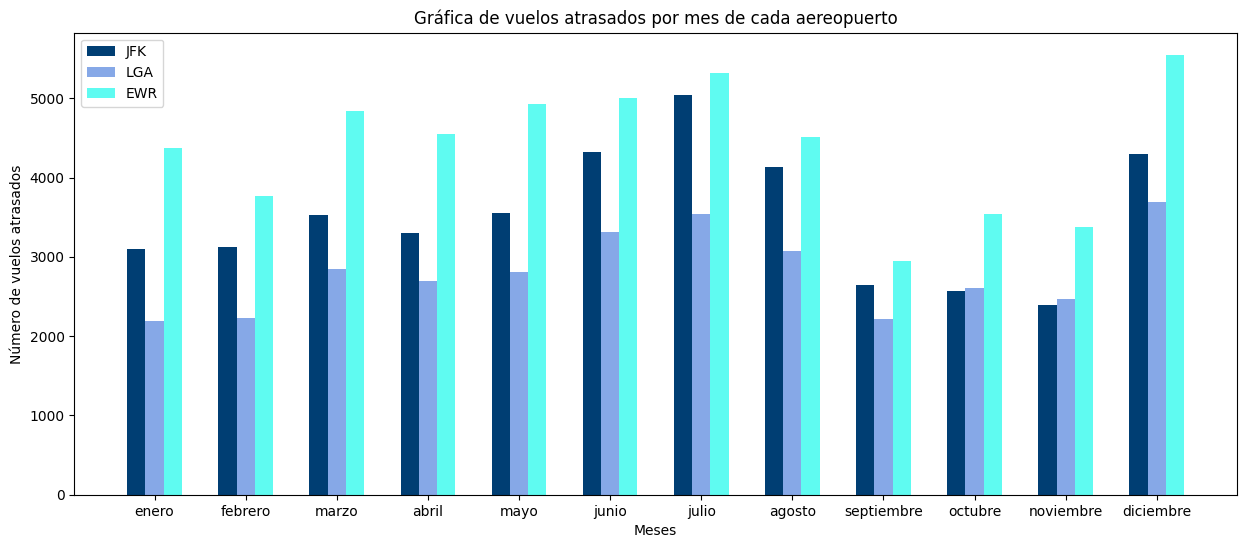


Menu de Opciones

• Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.
• Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.
• Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada (Tiempo en aire o Distancia).
• Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.
• Ingresa e, para realizar un resumen según el criterio (Distancia o Tiempo) seleccionado y una fecha.
• Ingresa f, para realizar un conteo de aviones según el aeropuerto y el número de vuelos realizados
• Ingrese g, para crear gráfica de barras de número de vuelos atrasados cada mes según el aereopuerto de orígen.
• Ingresa x, para cerrar sesion.

Seleccione una opcion
---> g

a) Gráfica vuelos atrasados aereopuerto John F. Kennedy
b) Gráfica vuelos atrasados aereopuerto La Guardia
c) Gráfica vuelos atrasados aereopuerto Newark Liberty
d) Gráfica vuelos atr

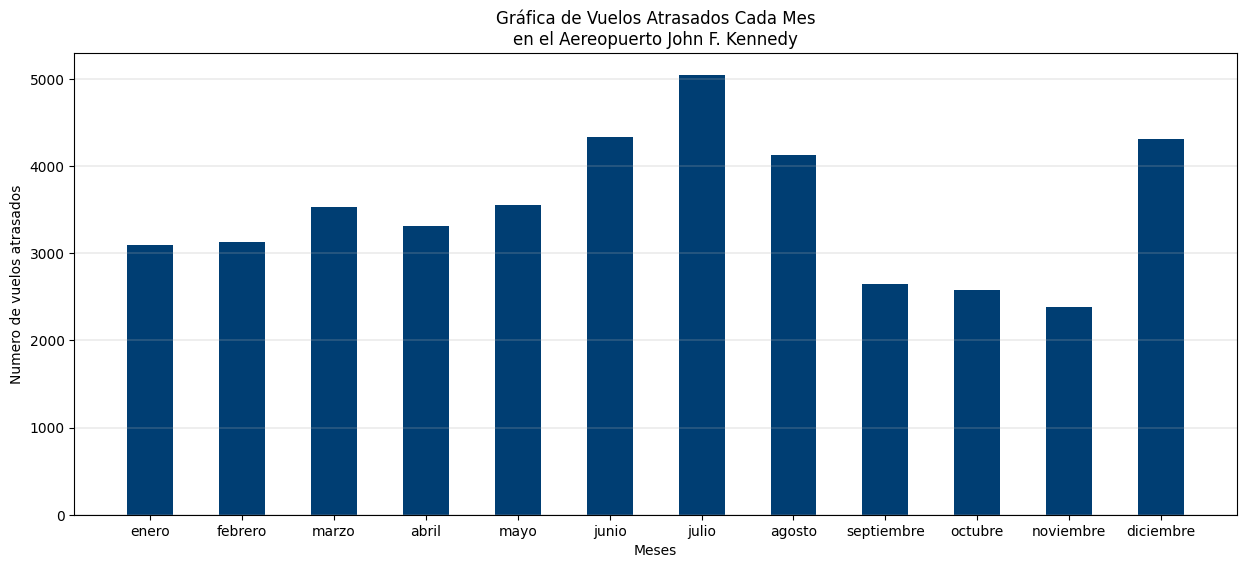


Menu de Opciones

• Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.
• Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.
• Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada (Tiempo en aire o Distancia).
• Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.
• Ingresa e, para realizar un resumen según el criterio (Distancia o Tiempo) seleccionado y una fecha.
• Ingresa f, para realizar un conteo de aviones según el aeropuerto y el número de vuelos realizados
• Ingrese g, para crear gráfica de barras de número de vuelos atrasados cada mes según el aereopuerto de orígen.
• Ingresa x, para cerrar sesion.

Seleccione una opcion
---> g

a) Gráfica vuelos atrasados aereopuerto John F. Kennedy
b) Gráfica vuelos atrasados aereopuerto La Guardia
c) Gráfica vuelos atrasados aereopuerto Newark Liberty
d) Gráfica vuelos atr

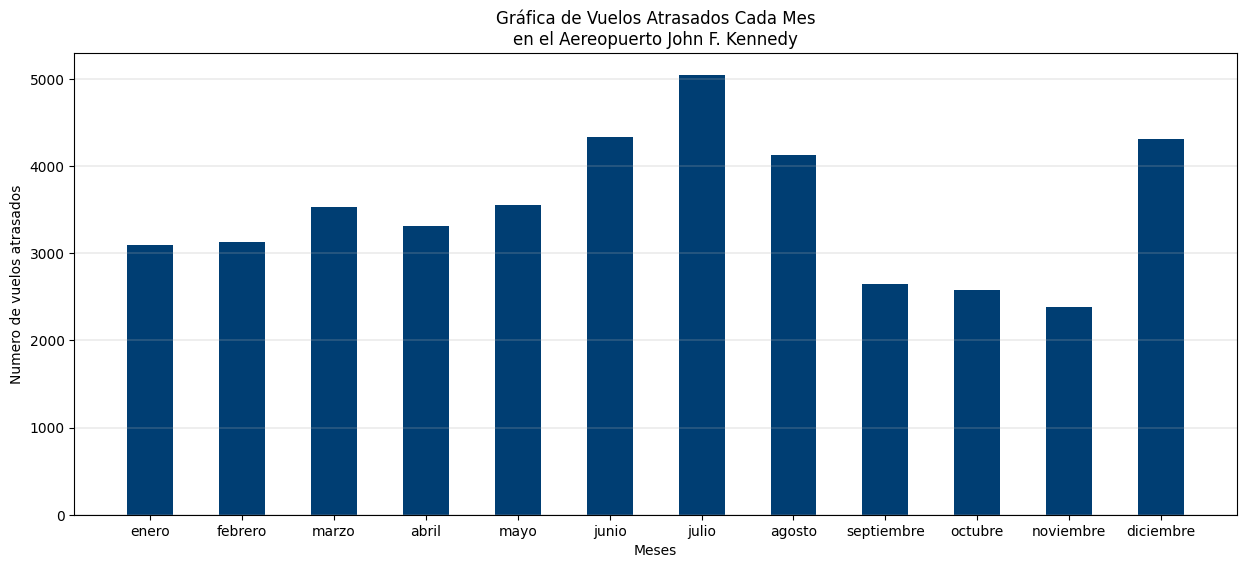


Menu de Opciones

• Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.
• Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.
• Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada (Tiempo en aire o Distancia).
• Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.
• Ingresa e, para realizar un resumen según el criterio (Distancia o Tiempo) seleccionado y una fecha.
• Ingresa f, para realizar un conteo de aviones según el aeropuerto y el número de vuelos realizados
• Ingrese g, para crear gráfica de barras de número de vuelos atrasados cada mes según el aereopuerto de orígen.
• Ingresa x, para cerrar sesion.

Seleccione una opcion
---> g

a) Gráfica vuelos atrasados aereopuerto John F. Kennedy
b) Gráfica vuelos atrasados aereopuerto La Guardia
c) Gráfica vuelos atrasados aereopuerto Newark Liberty
d) Gráfica vuelos atr

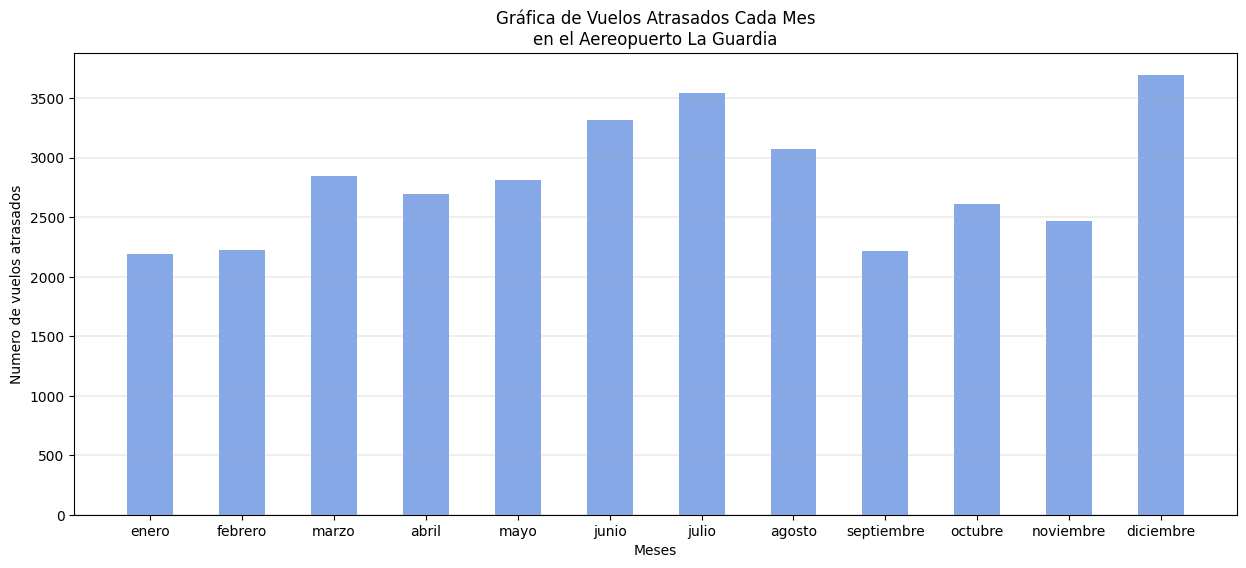


Menu de Opciones

• Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.
• Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.
• Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada (Tiempo en aire o Distancia).
• Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.
• Ingresa e, para realizar un resumen según el criterio (Distancia o Tiempo) seleccionado y una fecha.
• Ingresa f, para realizar un conteo de aviones según el aeropuerto y el número de vuelos realizados
• Ingrese g, para crear gráfica de barras de número de vuelos atrasados cada mes según el aereopuerto de orígen.
• Ingresa x, para cerrar sesion.

Seleccione una opcion
---> g

a) Gráfica vuelos atrasados aereopuerto John F. Kennedy
b) Gráfica vuelos atrasados aereopuerto La Guardia
c) Gráfica vuelos atrasados aereopuerto Newark Liberty
d) Gráfica vuelos atr

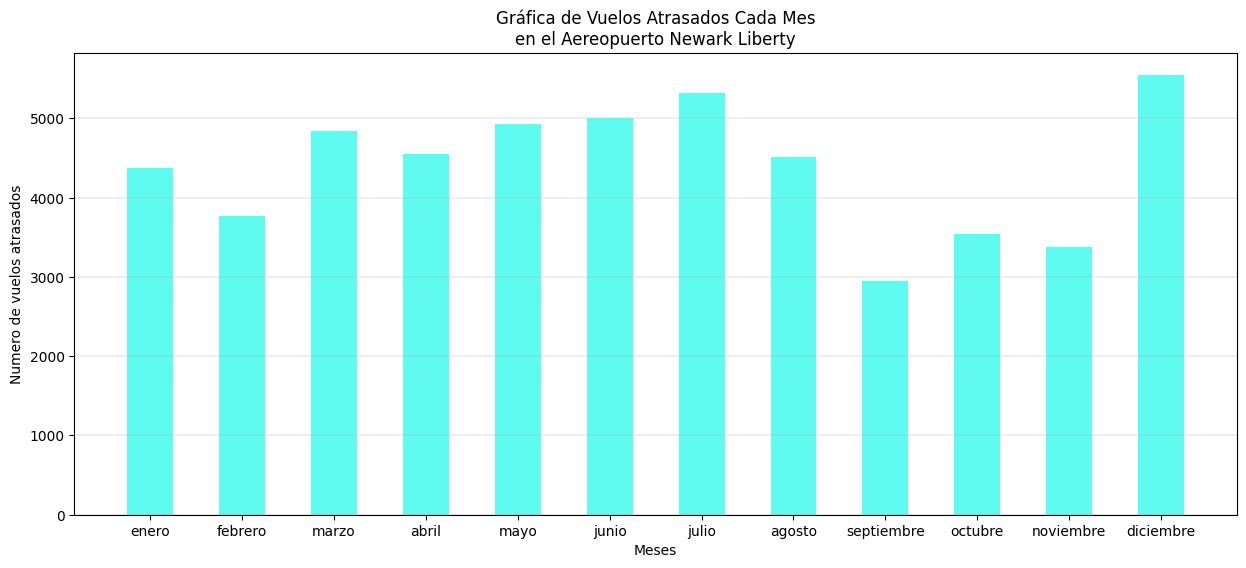


Menu de Opciones

• Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.
• Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.
• Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada (Tiempo en aire o Distancia).
• Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.
• Ingresa e, para realizar un resumen según el criterio (Distancia o Tiempo) seleccionado y una fecha.
• Ingresa f, para realizar un conteo de aviones según el aeropuerto y el número de vuelos realizados
• Ingrese g, para crear gráfica de barras de número de vuelos atrasados cada mes según el aereopuerto de orígen.
• Ingresa x, para cerrar sesion.

Seleccione una opcion
---> x
Menú de Inicio:

1) Log in
2) Creacion de nuevo usuario
3) Salir

Selecciona alguna de las opciones (1, 2 o 3)
---> 3

El programa se ha finalizado.
¡¡Nos vemos pronto!!


In [166]:
def main():
  bienvenida()
  credentials = login_menu()

  while credentials != False:
    print("\nMenu de Opciones\n")
    print("• Ingresa a, para contabilizar la cantidad de vuelos según su origen y destino.")
    print("• Ingresa b, para contabilizar el total de vuelos según su origen y una determinada fecha.")
    print("• Ingresa c, para realizar un resumen estadístico de los vuelos según el aeropuerto de origen y la variable seleccionada (Tiempo en aire o Distancia).")
    print("• Ingresa d, para realizar un resumen de retrasos de los vuelos según el aeropuerto de origen.")
    print("• Ingresa e, para realizar un resumen según el criterio (Distancia o Tiempo) seleccionado y una fecha.")
    print("• Ingresa f, para realizar un conteo de aviones según el aeropuerto y el número de vuelos realizados")
    print("• Ingrese g, para crear gráfica de barras de número de vuelos atrasados cada mes según el aereopuerto de orígen.")
    print("• Ingresa x, para cerrar sesion.")
    function_option = input("\nSeleccione una opcion\n---> ")
    function_option.lower()

    if function_option == 'a':
      cantidad_vuelos()
    elif function_option == 'b':
      total_vuelos()
    elif function_option == 'c':
      resumen_estadistico()
    elif function_option == 'd':
      resumen_status()
    elif function_option == 'e':
      resumen_criterio()
    elif function_option == 'f':
      conteo_aviones()
    elif function_option == 'g':
      grafica()
    elif function_option == 'x':
      credentials = login_menu()
    else:
      print("\nOpción no valida")

main()